# 02 — Factor Stability Analysis

**Goal:** Measure which factors have predictive value (IC analysis) before training the model.

The Information Coefficient (IC) = Spearman correlation between factor(season N) and fpts_per_game(season N+1).

Strong factors → include in Ridge model  
Weak factors → downweight or exclude

Expected results:
- STRONG: target_share, rush_share, air_yard_share, wopr, team_pass_rate
- MODERATE: catch_rate, aDOT, epa_per_dropback (QB), cpoe, yac_per_rec
- WEAK: TD rates, INT rates, explosive_play_rate, stuff_rate

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TRAINING_SEASONS, POSITION_FEATURES, POSITIONS
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.stability import (
    compute_factor_stability,
    compute_yoy_factor_correlation,
    plot_stability_heatmap,
    plot_factor_ic_bar,
)

print('Imports OK')

Imports OK


## 1. Build Feature Matrix

In [2]:
# Assemble the full 5-year feature matrix
# This will take a few minutes on first run (heavy PBP processing)
print('Building feature matrix...')
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
print(f'Feature matrix: {feature_matrix.shape}')
print(f'\nRows per position:')
print(feature_matrix.groupby(['position', 'season']).size().unstack(fill_value=0))

Building feature matrix...
Assembling feature matrix for seasons: [2020, 2021, 2022, 2023, 2024]
  Computing opportunity factors...
  Computing efficiency factors...
  Computing context factors...
  Computing trend factors...
  Merging factors...
  Feature matrix: 1452 rows, 101 columns
  Saving to cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Feature matrix: (1452, 101)

Rows per position:
season    2020  2021  2022  2023  2024
position                              
QB          44    44    48    50    46
RB          83    88    79    78    80
TE          46    46    45    44    46
WR         119   120   114   115   117


In [3]:
# Build YoY pairs (season N features → season N+1 target)
yoy = build_yoy_pairs(feature_matrix)
print(f'YoY pairs: {len(yoy)}')
print(f'\nPairs per position:')
print(yoy.groupby(['position', 'season']).size().unstack(fill_value=0))

YoY pairs: 814

Pairs per position:
season    2020  2021  2022  2023
position                        
QB          30    36    31    31
RB          61    56    56    59
TE          31    28    33    33
WR          83    80    82    84


## 2. IC Analysis — All Factors

In [4]:
# All factors in the feature matrix (excluding metadata columns)
meta_cols = ['player_id', 'player_name', 'position', 'team', 'season', 'age',
             'fpts', 'fpts_per_game', 'games_played', 'next_fpts', 'trend_class']
all_factors = [c for c in yoy.columns if c not in meta_cols]
print(f'Factors to evaluate: {len(all_factors)}')

Factors to evaluate: 91


In [5]:
# Compute IC for all factors
stability = compute_factor_stability(yoy, all_factors)
print(stability[['mean_ic', 'std_ic', 'ic_ir', 'stability_tier']].to_string())

                                mean_ic    std_ic      ic_ir     stability_tier
factor                                                                         
snap_percentage                0.524175  0.031112  16.848075           MODERATE
dropbacks                      0.428253  0.122965   3.482721           MODERATE
dropbacks_per_game             0.376209  0.106065   3.546961           MODERATE
target_share_late              0.333894  0.027330  12.217177           MODERATE
target_share_full              0.316343  0.035990   8.789784           MODERATE
targets_per_game               0.314354  0.036254   8.670959           MODERATE
targets                        0.308502  0.044310   6.962407           MODERATE
targets_recv                   0.308502  0.044310   6.962407           MODERATE
target_share                   0.297436  0.053766   5.532029               WEAK
td_rate                        0.291331  0.040866   7.128898               WEAK
wopr_late                      0.280825 

In [6]:
# IC IR summary
print('Factors with IC IR > 1.0 (strong signal):')
print(stability[stability['ic_ir'] > 1.0][['mean_ic', 'ic_ir', 'stability_tier']])

print('\nFactors with IC IR < 0.5 (weak signal — consider excluding):')
print(stability[stability['ic_ir'] < 0.5][['mean_ic', 'ic_ir', 'stability_tier']])

Factors with IC IR > 1.0 (strong signal):
                         mean_ic      ic_ir stability_tier
factor                                                    
snap_percentage         0.524175  16.848075       MODERATE
dropbacks               0.428253   3.482721       MODERATE
dropbacks_per_game      0.376209   3.546961       MODERATE
target_share_late       0.333894  12.217177       MODERATE
target_share_full       0.316343   8.789784       MODERATE
targets_per_game        0.314354   8.670959       MODERATE
targets                 0.308502   6.962407       MODERATE
targets_recv            0.308502   6.962407       MODERATE
target_share            0.297436   5.532029           WEAK
td_rate                 0.291331   7.128898           WEAK
wopr_late               0.280825   9.456397           WEAK
targets_rb              0.264514   4.893668           WEAK
wopr_full               0.237801   7.777394           WEAK
rz_target_share         0.227526   3.172956           WEAK
wopr          

## 3. IC Heatmap (Factor × Season)

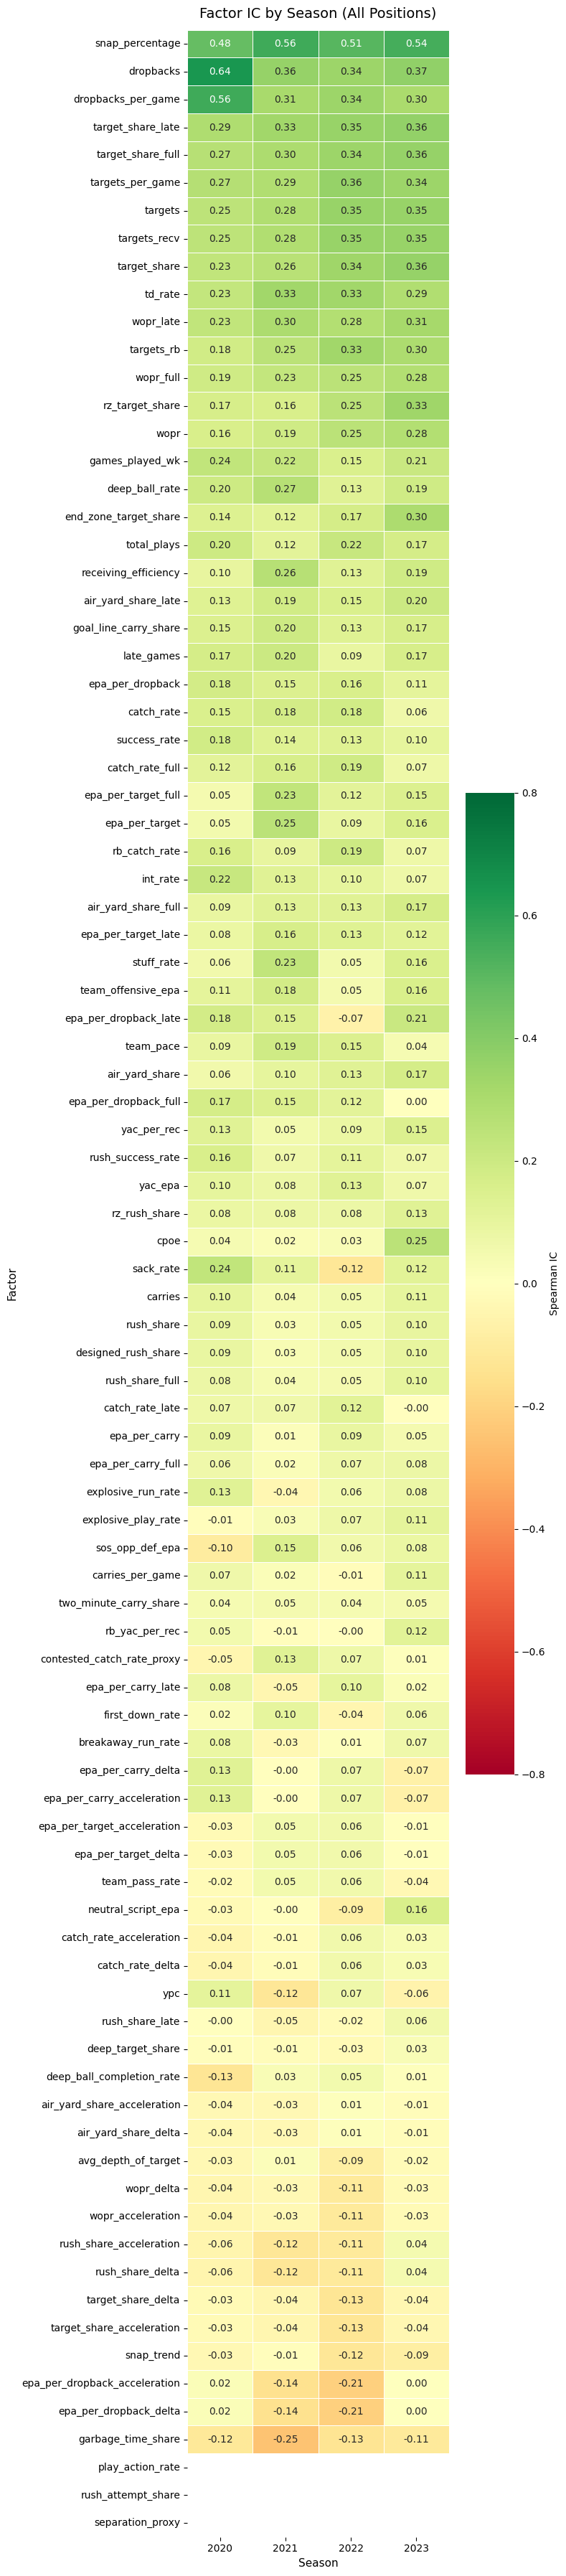

In [7]:
fig = plot_stability_heatmap(stability, title='Factor IC by Season (All Positions)')
plt.show()

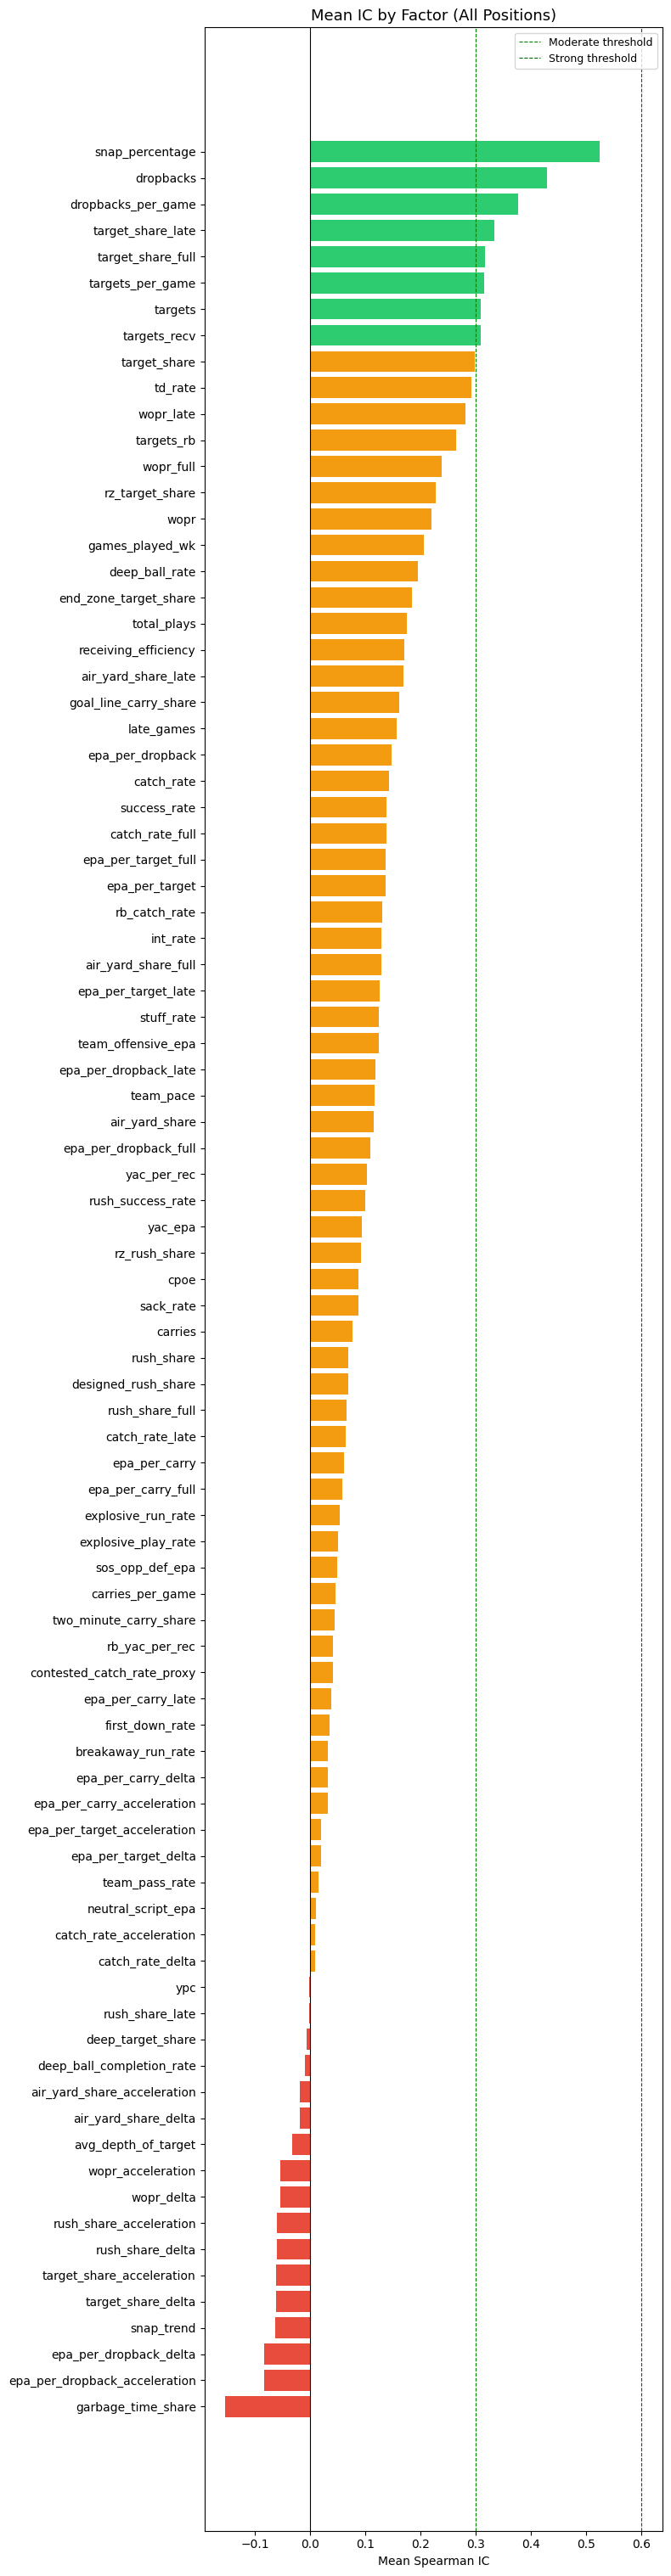

In [8]:
fig = plot_factor_ic_bar(stability, title='Mean IC by Factor (All Positions)')
plt.show()

## 4. Position-Specific IC Analysis

In [9]:
for pos in POSITIONS:
    pos_yoy = yoy[yoy['position'] == pos]
    if len(pos_yoy) < 10:
        continue
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_yoy.columns]
    pos_stability = compute_factor_stability(pos_yoy, pos_factors)
    
    print(f'\n=== {pos} IC Analysis ===')
    print(pos_stability[['mean_ic', 'std_ic', 'ic_ir', 'stability_tier']].to_string())


=== QB IC Analysis ===
                     mean_ic    std_ic     ic_ir     stability_tier
factor                                                             
td_rate             0.431684  0.088448  4.880679           MODERATE
epa_per_dropback    0.422805  0.162091  2.608437           MODERATE
games_played        0.371408  0.149135  2.490418           MODERATE
cpoe                0.330072  0.138986  2.374857           MODERATE
deep_ball_rate      0.214973  0.152426  1.410337               WEAK
team_pace           0.153809  0.123622  1.244185               WEAK
int_rate           -0.157386  0.126631 -1.242870               WEAK
sack_rate          -0.216527  0.029766 -7.274365               WEAK
rush_attempt_share       NaN       NaN       NaN  INSUFFICIENT DATA

=== RB IC Analysis ===
                     mean_ic    std_ic      ic_ir stability_tier
factor                                                          
snap_percentage     0.565186  0.050118  11.277104       MODERATE
rush_shar

## 5. YoY Factor Stickiness (Factor-to-Factor)

In [10]:
# How stable are the factors themselves year-over-year?
# This is different from IC (which measures factor → outcome).
# High YoY correlation = the factor is a persistent player characteristic.
yoy_corr = compute_yoy_factor_correlation(feature_matrix, all_factors)
print('YoY factor correlation (factor persistence):')
print(yoy_corr[['pearson_yoy', 'spearman_yoy', 'n_pairs', 'yoy_tier']].head(20).to_string())

YoY factor correlation (factor persistence):
                     pearson_yoy  spearman_yoy  n_pairs yoy_tier
factor                                                          
dropbacks_per_game      0.943807      0.756173      155   STRONG
avg_depth_of_target     0.916483      0.894860      693   STRONG
carries_per_game        0.898255      0.899504      542   STRONG
air_yard_share_full     0.886282      0.893938      629   STRONG
air_yard_share          0.870534      0.884354      695   STRONG
rush_share_full         0.844556      0.906587      471   STRONG
rush_share              0.827352      0.899371      542   STRONG
designed_rush_share     0.827352      0.899371      542   STRONG
wopr_full               0.826413      0.835674      629   STRONG
carries                 0.820729      0.896998      542   STRONG
targets_per_game        0.815186      0.803217      695   STRONG
wopr                    0.808034      0.824117      695   STRONG
snap_percentage         0.796067      0.80804

## 6. Factor Correlation Matrix (Multicollinearity Check)

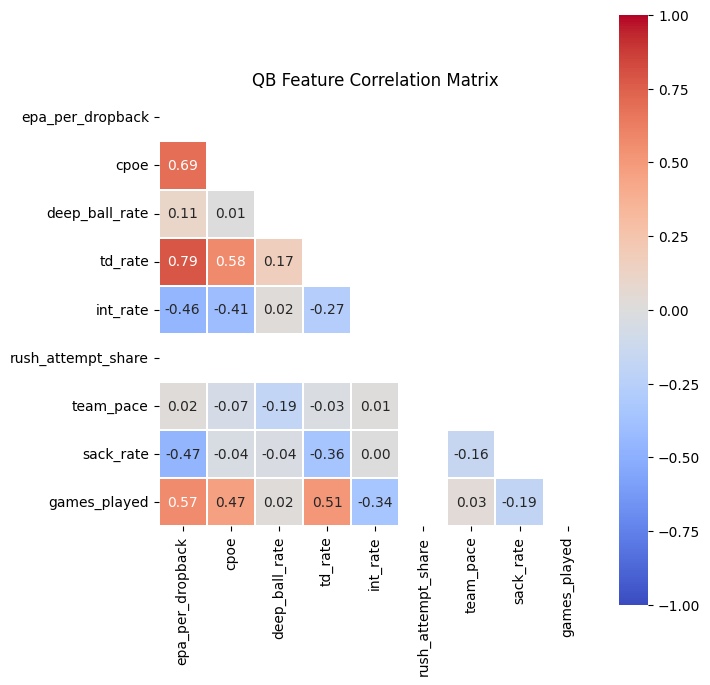

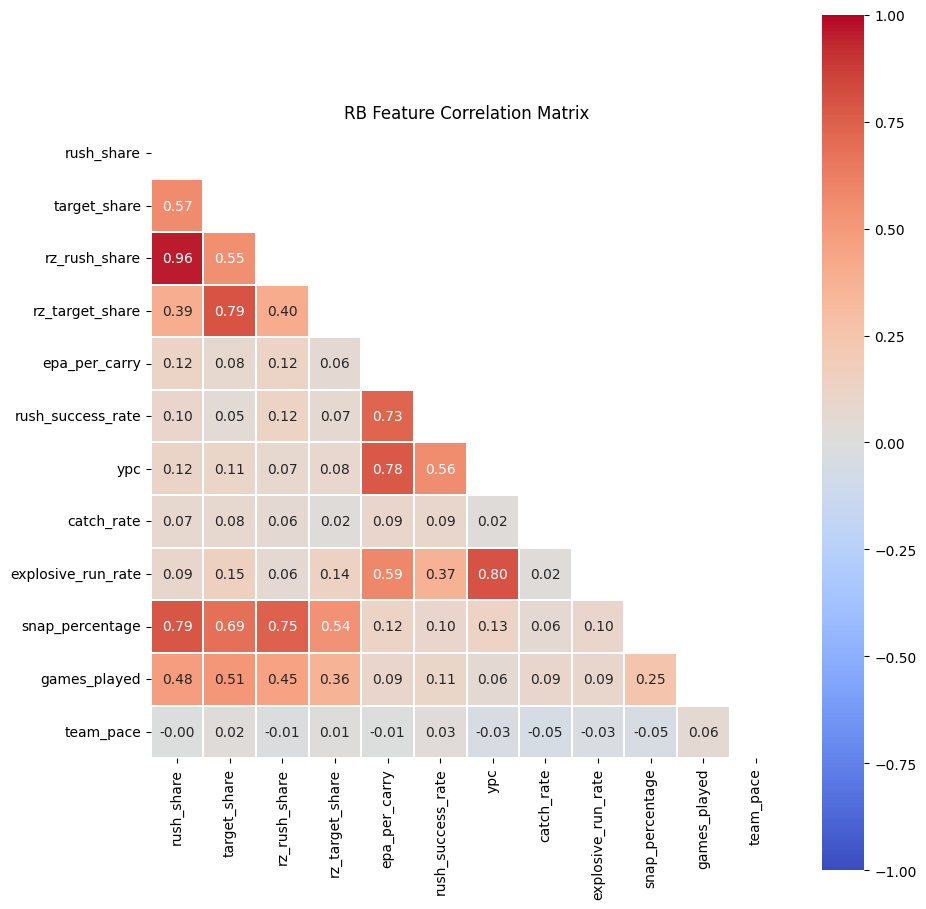

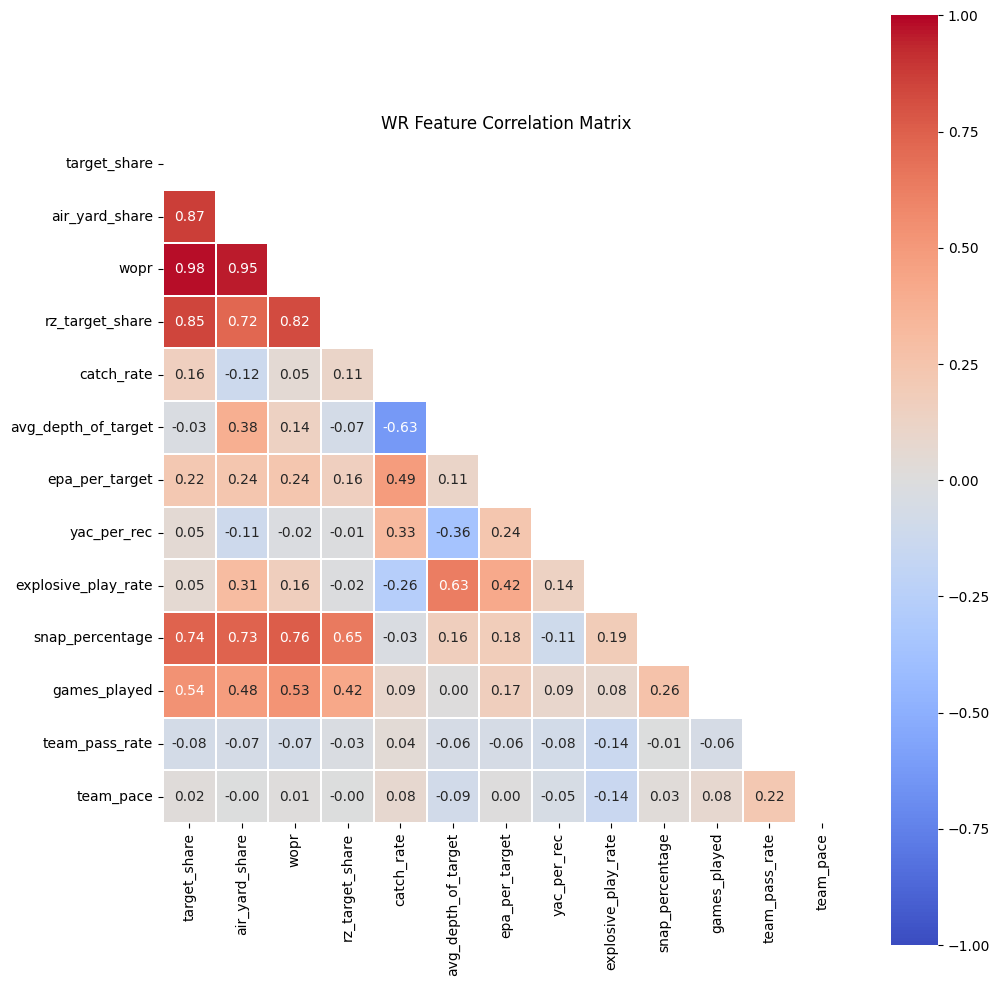

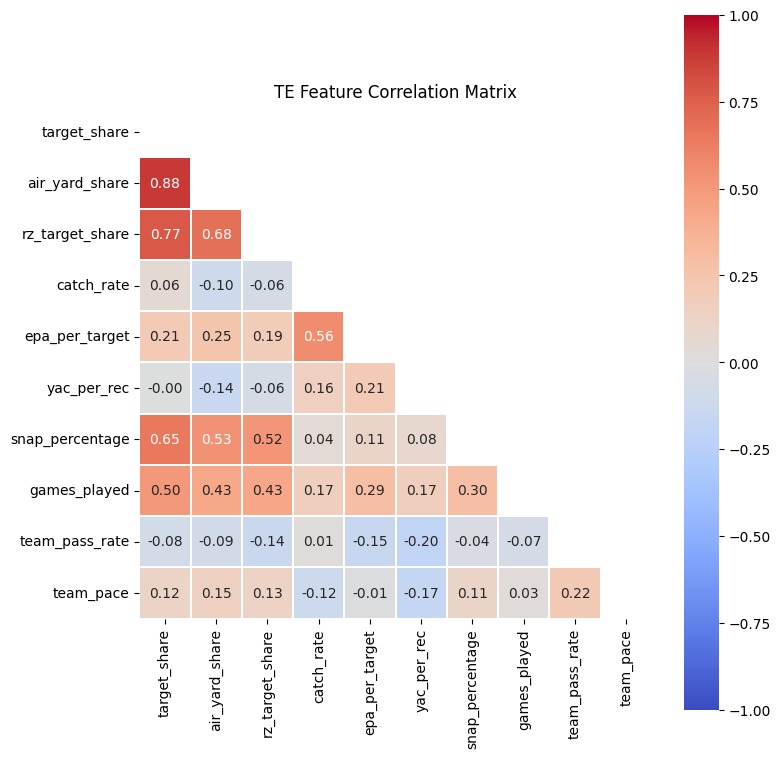

In [11]:
# Check correlation among model features (high correlation = potential multicollinearity)
# Ridge regression handles this, but it's useful to know
for pos in POSITIONS:
    pos_data = feature_matrix[feature_matrix['position'] == pos]
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_data.columns]
    
    corr_matrix = pos_data[pos_factors].corr()
    
    fig, ax = plt.subplots(figsize=(max(6, len(pos_factors) * 0.8), max(5, len(pos_factors) * 0.8)))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, ax=ax, cmap='coolwarm',
        center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
        square=True, linewidths=0.3
    )
    ax.set_title(f'{pos} Feature Correlation Matrix', fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Top Factors — Scatter Plots

Plot top 3 most stable factors vs. next-year PPR for each position.

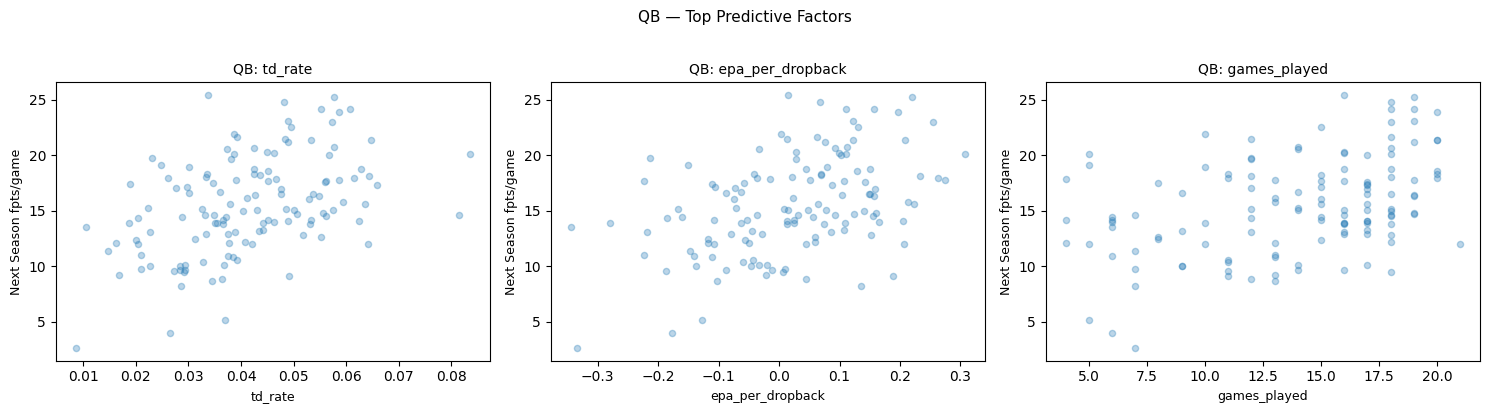

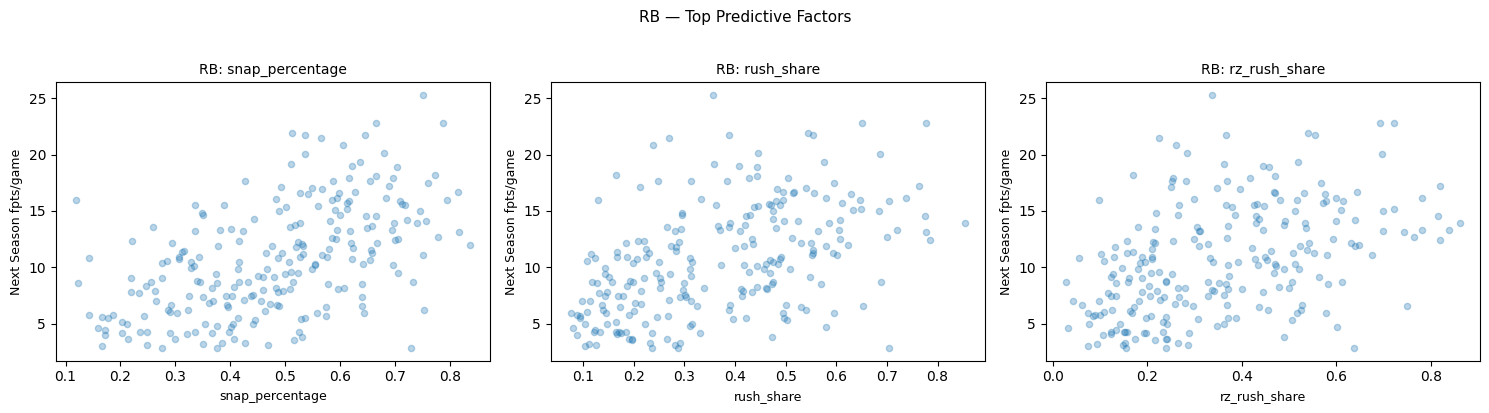

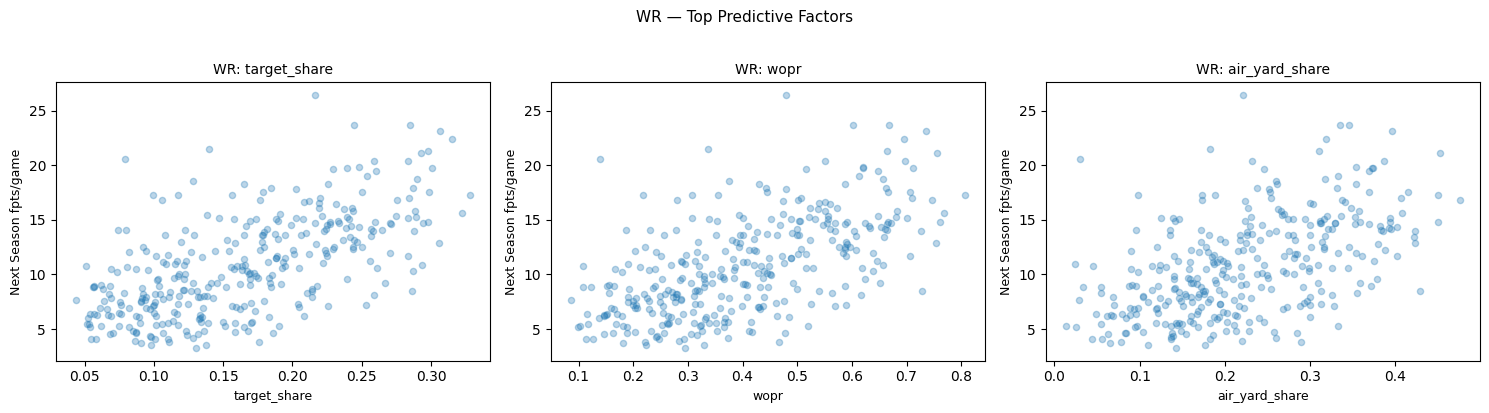

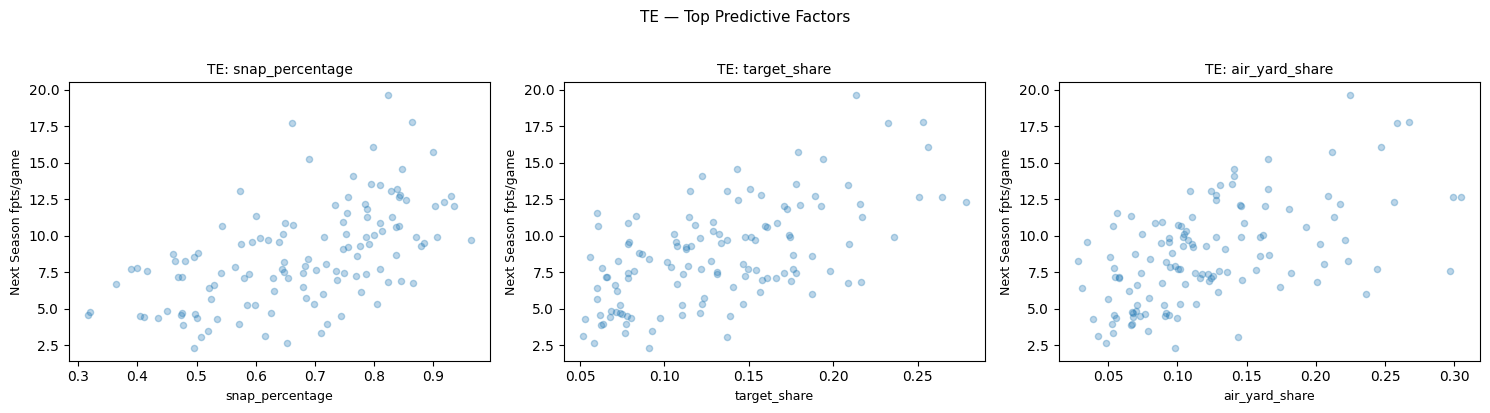

In [12]:
for pos in POSITIONS:
    pos_yoy = yoy[yoy['position'] == pos].dropna(subset=['next_fpts'])
    if len(pos_yoy) < 10:
        continue
    
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_yoy.columns]
    pos_stability = compute_factor_stability(pos_yoy, pos_factors)
    top3 = pos_stability.dropna(subset=['mean_ic']).head(3).index.tolist()
    
    if not top3:
        continue
    
    fig, axes = plt.subplots(1, min(3, len(top3)), figsize=(5 * min(3, len(top3)), 4))
    if len(top3) == 1:
        axes = [axes]
    
    for ax, factor in zip(axes, top3):
        valid = pos_yoy[[factor, 'next_fpts']].dropna()
        ax.scatter(valid[factor], valid['next_fpts'], alpha=0.3, s=20)
        ax.set_xlabel(factor, fontsize=9)
        ax.set_ylabel('Next Season fpts/game', fontsize=9)
        ax.set_title(f'{pos}: {factor}', fontsize=10)
    
    plt.suptitle(f'{pos} — Top Predictive Factors', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()